# Build Compound Event Catalog - Inland

Build the copula-joint design catalog from reviewed USGS streamflow records and direct AORC SST rainfall members. 

1. Source inventory: show driver libraries and marginal evidence
2. Extract POT events
3. Audit co-occurrence
4. Fit the copula
5. Sample AND-labeled design events
6. Produce Resilience-Design catalogue of 500 events

In [1]:
# imports, workspace path, and catalog runtime.
import sys
from pathlib import Path

location_root = Path("..").resolve()
repo_root = location_root.parents[1]
src_root = repo_root / "src"
sys.path.insert(0, str(src_root))
import geopandas as gpd
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from IPython.display import display

from pyextremes import get_extremes
import pyvinecopulib as pvc
import yaml

# distribution, severity, and scaling plots.
from design_events import plotting as P
# paths and severity bands.
from design_events.build_events.workflow import (
    assign_severity_bands,
    load_runtime,
    materialize_inland_catalog_outputs,
)

pd.set_option("display.max_columns", 80)
plt.style.use("seaborn-v0_8-whitegrid")

runtime = load_runtime(location_root)
config = runtime.config
paths = runtime.runtime_paths
location_name = runtime.location_name


## Design Event Catalogue Parameters

 **importance-sampling and resource-allocation design** — Every selected row keeps its `probability_weight`, so enriching this set toward tail-heavy events does not bias the annualised estimate (Average Annual Outcome / EAD) — the weights correct the integral. This allows for oversampling the interesting events without distorting the risk number.

Design event split is user-driven. For this case, a tail-heavy 5/20/20/25/30 split is selected for 500 events.


In [ ]:
# design-event simulation budget and severity mix.
resilience_stress_training = {
    "target_event_count": 500,
    "severity_band_fractions": {
        "mild": 0.05,
        "common": 0.20,
        "significant": 0.20,
        "rare": 0.25,
        "extreme": 0.30,
    },
    "benchmark_return_period_years": [10, 50, 100, 500],
}
config["resilience_stress_training"] = resilience_stress_training
config.setdefault("events", {})["target_event_count"] = resilience_stress_training["target_event_count"]

## Stage 1 - Source Inventory and Member Libraries

Start with the reviewed source artifacts and member libraries before fitting anything. Rainfall is the inland design driver; antecedent soil moisture is a conditioning state; streamflow is retained as the Wflow-response validation and single-K amplification anchor.


In [ ]:
# source paths, POT settings, member libraries, and event-catalog policy.
dependence = config["event_catalog"]["dependence"]
cooccurrence = dependence.get("cooccurrence", {})
pairing = config["event_catalog"].get("pairing", {})

# POT quantile: upper-tail cutoff; 0.95 keeps large events while retaining enough peaks to fit.
pot_quantile = float(cooccurrence.get("threshold_quantile", 0.95))
# Decluster window: storm-separation window; 120 hours avoids double-counting one hydrograph.
decluster_window_hours = float(cooccurrence.get("decluster_window_hours", 120))
min_peak_distance = pd.Timedelta(hours=decluster_window_hours)

copula_seed = int(dependence.get("copula_seed", 0))
target_design_events = int(resilience_stress_training["target_event_count"])
benchmark_return_periods = resilience_stress_training["benchmark_return_period_years"]

# Rainfall is the inland design driver; discharge is the Wflow response. The
# streamflow POT at the Primary Reference Gage is a calibration/validation + single-K anchor.
primary_reference_gage = str(config["inland_coupling"]["amplification"]["primary_reference_gage"])

streamflow_csv = paths["usgs_streamgages_root"] / "streamflow_records.csv"
rainfall_csv = paths["aorc_sst_rainfall_members_csv"]
soil_moisture_csv = paths["nwm_soil_moisture_csv"]
output_catalog_csv = paths["catalog_root"] / "inland_design_event_catalog.csv"

rainfall_members = pd.read_csv(rainfall_csv)
soil_moisture_members = pd.read_csv(soil_moisture_csv)
soil_moisture_members.attrs["source_file"] = str(soil_moisture_csv)
streamflow_records_all = pd.read_csv(streamflow_csv, parse_dates=["time"], dtype={"site_no": str})

rainfall_time_column = next(column for column in ["storm_start", "storm_date", "time"] if column in rainfall_members)
rainfall_value_column = next(
    column for column in ["mean_precip_mm", "max_precip_mm", "mean", "max"] if column in rainfall_members
)
soil_value_column = next(
    (column for column in ["SOILSAT_TOP", "SOIL_M", "soil_moisture"] if column in soil_moisture_members),
    None,
)

source_inventory = pd.DataFrame([
    {
        "driver": "rainfall",
        "source": "Direct AORC SST",
        "role": "inland design driver (rainfall marginal / POT)",
        "path": str(rainfall_csv),
        "status": "complete" if rainfall_csv.exists() else "missing",
        "member_rows": len(rainfall_members),
        "value_column": rainfall_value_column,
    },
    {
        "driver": "antecedent soil moisture",
        "source": "NWM retrospective",
        "role": "antecedent conditioning state (not a copula axis)",
        "path": str(soil_moisture_csv),
        "status": "complete" if soil_moisture_csv.exists() else "missing",
        "member_rows": len(soil_moisture_members),
        "value_column": soil_value_column,
    },
    {
        "driver": "streamflow",
        "source": f"USGS Primary Reference Gage {primary_reference_gage}",
        "role": "Wflow-response calibration/validation + single-K anchor (NOT a design driver)",
        "path": str(streamflow_csv),
        "status": "complete" if streamflow_csv.exists() else "missing",
        "member_rows": len(streamflow_records_all),
        "value_column": "discharge_cfs",
    },
])

display(source_inventory)
display(pd.Series({
    "location": location_name,
    "design_driver": "rainfall + antecedent moisture",
    "primary_reference_gage": primary_reference_gage,
    "pot_quantile": pot_quantile,
    "decluster_window_hours": decluster_window_hours,
    "copula_seed": copula_seed,
    "target_design_events": target_design_events,
    "benchmark_return_periods": benchmark_return_periods,
}, name="event_catalog_parameters"))
P.plot_rainfall(rainfall_members);
rainfall_members.head(5)


## Stage 2 - Streamflow validation anchor (Primary Reference Gage)

The streamflow POT at the Primary Reference Gage is the **Wflow-response calibration/validation + single-K anchor**, not the design frequency axis. The design driver is rainfall (Stage 3). For `austin_p5u`, the dominant inflow is the Highland Lakes-regulated Colorado mainstem (no on-reach gage); Barton Creek anchors the rainfall-runoff response, while the regulated mainstem warrants reservoir-aware handling.


### 2.1 Raw USGS Streamflow Records

Normalize the reviewed USGS site identifiers, isolate the Primary Reference Gage, and plot the record used for the streamflow validation anchor.


In [ ]:
# reference-gage discharge record for validation anchor.
# Normalize USGS site numbers because CSV round-trips and spreadsheet tools can
# turn leading-zero identifiers into numeric-looking strings such as "2094500.0".
def normalize_site_no(value):
    text = "" if pd.isna(value) else str(value).strip()
    if text.endswith(".0"):
        text = text[:-2]
    return text.zfill(8) if text.isdigit() and len(text) < 8 else text

streamflow_records_all["site_no"] = streamflow_records_all["site_no"].map(normalize_site_no)
primary_reference_gage_normalized = normalize_site_no(primary_reference_gage)

# The streamflow POT is the in-domain validation anchor at the Primary Reference
# Gage, not the retired cross-basin max-envelope and not the design driver.
reference_records = streamflow_records_all[
    streamflow_records_all["site_no"] == primary_reference_gage_normalized
].copy()
df_streamflow = reference_records.set_index("time")["discharge_cfs"].sort_index().to_frame()

# Plotting helpers expect the network-style long table: one row per site/time/value.
network_streamflow_records = df_streamflow.reset_index().assign(site_no=primary_reference_gage_normalized)
network_streamflow_records = network_streamflow_records[["site_no", "time", "discharge_cfs"]]

# Show the hydrograph neighborhood around the largest observed flow so the anchor
# record can be visually checked before extracting independent POT peaks.
peak_time = df_streamflow["discharge_cfs"].idxmax()
window_slice = (peak_time - pd.Timedelta(days=45), peak_time + pd.Timedelta(days=45))
window = df_streamflow.loc[window_slice[0]:window_slice[1], "discharge_cfs"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(window.index, window.values, lw=1.0)
axes[0].set_title(
    f"Reference-gage {primary_reference_gage_normalized} discharge "
    f"({window_slice[0]:%Y-%m-%d} to {window_slice[1]:%Y-%m-%d})"
)
axes[0].set_ylabel("discharge [cfs]")
axes[0].grid(True, alpha=0.3)
axes[1].hist(df_streamflow["discharge_cfs"].dropna().values, bins=60, color="0.4", alpha=0.85)
axes[1].set_title(f"Primary Reference Gage {primary_reference_gage_normalized} record (n={len(df_streamflow):,})")
axes[1].set_xlabel("reference-gage discharge [cfs]")
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

display(pd.Series({
    "primary_reference_gage": primary_reference_gage_normalized,
    "reference_gage_rows": len(reference_records),
    "streamflow_start": df_streamflow.index.min(),
    "streamflow_end": df_streamflow.index.max(),
    "annual_mean_cfs": round(float(df_streamflow["discharge_cfs"].mean()), 1),
    "median_baseflow_cfs": round(float(df_streamflow["discharge_cfs"].median()), 1),
    "note": "Wflow-readiness anchor; streamflow is validation/amplification evidence, not the design driver.",
}, name="reference_gage_validation_anchor"))


### 2.2 Peaks-over-threshold Extraction

Use the configured POT threshold and declustering window to extract independent streamflow events.

In [ ]:
# independent streamflow peaks from the configured POT threshold.
ts_streamflow = df_streamflow["discharge_cfs"].dropna()
# POT threshold flow from the configured upper-tail quantile.
threshold_cfs = float(ts_streamflow.quantile(pot_quantile))
# pyextremes extracts independent Peaks Over Threshold; `r` is the declustering
# separation that prevents one multi-day hydrograph from contributing many peaks.
extremes = get_extremes(
    ts=ts_streamflow,
    method="POT",
    threshold=threshold_cfs,
    r=min_peak_distance,
)

# Convert the pyextremes Series into the project member-table shape used by plots
# and downstream validation: value, event time, threshold, rank, and empirical RP.
df_pot = extremes.to_frame(name="peak_flow_cfs").sort_index()
record_years = max((ts_streamflow.index.max() - ts_streamflow.index.min()) / pd.Timedelta(days=365.25), 1.0)
event_rate_per_year = float(dependence.get("event_rate_per_year") or (len(df_pot) / record_years))
streamflow_pot_members = df_pot.assign(
    site_no=primary_reference_gage_normalized,
    event_time=df_pot.index,
    site_threshold_cfs=threshold_cfs,
    rank=lambda frame: frame["peak_flow_cfs"].rank(method="first", ascending=False).astype(int),
)
streamflow_pot_members["sample_rp_years"] = record_years / streamflow_pot_members["rank"]
streamflow_pot_members["sampling_region"] = np.where(streamflow_pot_members["sample_rp_years"] >= 50, "tail", "body")

P.plot_streamflow_pot_extraction(
    network_streamflow_records,
    streamflow_pot_members,
    threshold_quantile=pot_quantile,
    site_no=primary_reference_gage_normalized,
);
P.plot_streamflow_pot_members(streamflow_pot_members);
P.plot_return_periods(streamflow_pot_members);

display(pd.Series({
    "validation_anchor_gage": primary_reference_gage_normalized,
    "threshold_cfs": threshold_cfs,
    "independent_peak_events": len(df_pot),
    "record_years": round(record_years, 2),
    "configured_event_rate_per_year": event_rate_per_year,
}, name="streamflow_validation_pot"))
streamflow_pot_members.head()


### 2.3 AIC Model Selection (Exp vs GPD)

empirical CDF on the left and log-survival tail behavior on the right. The fitted streamflow GPD is used for inverse transformation in the simple inland copula below.


In [ ]:
# exponential/GPD tail-fit comparison for streamflow peaks.
streamflow_exceedances = (df_pot["peak_flow_cfs"] - threshold_cfs).clip(lower=0).to_numpy(dtype=float)
streamflow_exceedances = streamflow_exceedances[np.isfinite(streamflow_exceedances)]

# Fit exceedances above the POT threshold. The exponential is the simple
# memoryless tail; the GPD allows tail shape and is the usual POT limit model.
exp_params = stats.expon.fit(streamflow_exceedances, floc=0)
gpd_params = stats.genpareto.fit(streamflow_exceedances, floc=0)

# AIC gives a compact likelihood-penalized comparison for the two tail choices.
def _aic(log_likelihood, n_params):
    return 2 * n_params - 2 * log_likelihood

exp_aic = _aic(float(np.sum(stats.expon.logpdf(streamflow_exceedances, *exp_params))), 1)
gpd_aic = _aic(float(np.sum(stats.genpareto.logpdf(streamflow_exceedances, *gpd_params))), 2)
shape_sf, loc_sf, scale_sf = gpd_params

sorted_excess = np.sort(streamflow_exceedances)
grid = np.linspace(0, max(sorted_excess.max() * 1.08, 1.0), 400)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].plot(sorted_excess + threshold_cfs, np.linspace(0, 1, len(sorted_excess)), "o", color="0.3", alpha=0.7, label=f"empirical CDF ({len(sorted_excess):,} peaks)")
axes[0].plot(grid + threshold_cfs, stats.expon.cdf(grid, *exp_params), "--", color="steelblue", lw=1.4, label=f"EXP fit (AIC={exp_aic:.1f})")
axes[0].plot(grid + threshold_cfs, stats.genpareto.cdf(grid, *gpd_params), "-", color="crimson", lw=2.2, label=f"GPD fit (AIC={gpd_aic:.1f})")
axes[0].set_xlabel("peak discharge [cfs]")
axes[0].set_ylabel("F(q) = P(peak <= q)")
axes[0].set_title("Which distribution best matches the streamflow peaks?")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].grid(True, alpha=0.3)

n = len(sorted_excess)
emp_surv = 1.0 - (np.arange(1, n + 1) - 0.5) / n
axes[1].semilogy(sorted_excess + threshold_cfs, emp_surv, "o", color="0.3", alpha=0.7, label="empirical P(peak > q)")
axes[1].semilogy(grid + threshold_cfs, stats.expon.sf(grid, *exp_params), "--", color="steelblue", lw=1.4, label="EXP fit")
axes[1].semilogy(grid + threshold_cfs, stats.genpareto.sf(grid, *gpd_params), "-", color="crimson", lw=2.2, label="GPD fit")
axes[1].set_xlabel("peak discharge [cfs]")
axes[1].set_ylabel("P(peak > q) (log scale)")
axes[1].set_title("Tail diagnostic - Exp = straight line on log-survival axis")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].grid(True, alpha=0.3, which="both")
fig.tight_layout()
plt.show()

display(pd.DataFrame([
    {"distribution": "exp", "aic": exp_aic, "shape": np.nan, "scale": exp_params[-1]},
    {"distribution": "gpd", "aic": gpd_aic, "shape": shape_sf, "scale": scale_sf},
]).round(4))


### 2.4 Streamflow Return-period Curve

Trace the fitted streamflow tail into return-period space and overlay the same benchmark return periods used later for design-event coverage.


In [ ]:
# streamflow return-period curve from the selected tail model.
q_grid = grid + threshold_cfs
# Convert the conditional GPD survival of threshold exceedances into annual
# exceedance rate by multiplying by the observed/configured POT event rate.
annual_exceedance = event_rate_per_year * stats.genpareto.sf(grid, c=shape_sf, loc=loc_sf, scale=scale_sf)
rp_grid = 1.0 / np.clip(annual_exceedance, 1e-12, None)
observed = streamflow_pot_members.sort_values("peak_flow_cfs", ascending=True).copy()
observed["observed_rp_years"] = record_years / np.arange(len(observed), 0, -1)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observed["observed_rp_years"], observed["peak_flow_cfs"], "o", color="0.3", alpha=0.55, label="historical streamflow peaks")
ax.plot(rp_grid, q_grid, "-", color="crimson", lw=2, label="GPD fit")
for rp in benchmark_return_periods:
    if min(rp_grid) <= rp <= max(rp_grid):
        q_star = float(np.interp(np.log(rp), np.log(rp_grid), q_grid))
        ax.axvline(rp, ls=":", color="black", lw=1)
        ax.plot([rp], [q_star], "o", color="black", ms=5)
        ax.annotate(f"{int(rp)}-yr", xy=(rp, q_star), xytext=(rp, q_star * 1.03), fontsize=8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("return period [yr] (log)")
ax.set_ylabel("peak discharge [cfs] (log)")
ax.set_title("Streamflow return-period curve")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()
plt.show()


### 2.5 Stationarity Diagnostic on Selected Peaks

POT peaks through time with a Theil-Sen slope and a rank-correlation trend test.

In [ ]:
# stationarity check for selected streamflow peaks.
# A stationary POT sample supports using one historical event rate/tail model;
# strong trend evidence should trigger a reviewed nonstationary treatment.
peak_series = df_pot["peak_flow_cfs"].dropna().sort_index()
t_years = ((peak_series.index - peak_series.index.min()) / pd.Timedelta(days=365.25)).to_numpy(dtype=float)
y_peaks = peak_series.to_numpy(dtype=float)
ts_slope = stats.theilslopes(y_peaks, t_years, 0.95)
tau, trend_p = stats.kendalltau(t_years, y_peaks)
line_t = np.array([t_years.min(), t_years.max()])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(peak_series.index, y_peaks, "o", color="0.3", alpha=0.7, label="POT peaks")
ax.plot(
    [peak_series.index.min(), peak_series.index.max()],
    ts_slope.intercept + ts_slope.slope * line_t,
    "-",
    color="crimson",
    lw=2,
    label=f"Theil-Sen = {ts_slope.slope:+.1f} cfs/yr [{ts_slope.low_slope:+.1f}, {ts_slope.high_slope:+.1f}]",
)
note = "stationary" if trend_p >= 0.05 else "trend detected"
ax.set_title(f"Stationarity diagnostic: Kendall tau p={trend_p:.3f} ({note})")
ax.set_ylabel("peak discharge [cfs]")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Stage 3 - Rainfall-driven design catalog

Rainfall is the single stochastic design driver (POT marginal); antecedent soil moisture conditions each event; **discharge is the Wflow response, not a copula dimension** (inland coupling policy). Built with the isolated `build_inland_catalog` (the shared coastal vine is untouched).

In [10]:
# rainfall catalog build and historical-tail sampling.
from design_events.build_events.probability import build_inland_catalog

inland_result = build_inland_catalog(
    config,
    paths,
    rainfall_members=rainfall_members,
    soil_moisture_members=(soil_moisture_members if not soil_moisture_members.empty else None),
    streamflow_records=streamflow_records_all,
    reference_gage=primary_reference_gage,
)
df_catalog = inland_result.catalog
# stress-set provenance columns the Stage 7 coverage plots expect
df_catalog["sampling_scheme"] = "band_stratified_importance_rainfall"
df_catalog["event_set"] = "resilience_stress_training"
df_catalog["selection_role"] = "resilience_stress_training"

display(pd.Series({
    "design_rows": len(df_catalog),
    "design_driver": df_catalog["event_drivers"].iloc[0],
    "forcing_pairing_policy": df_catalog["forcing_pairing_policy"].iloc[0],
    "rainfall_marginal": type(inland_result.rainfall_marginal).__name__,
    "rainfall_analogs": int(df_catalog["rainfall_member_id"].nunique()),
    "probability_weight_sum": round(float(df_catalog["probability_weight"].sum()), 4),
}, name="inland_design_catalog"))
display(inland_result.budget_report)
df_catalog.head(5)


design_rows 500
design_driver rainfall
forcing_pairing_policy rainfall_marginal_with_antecedent_moisture_wfl...
rainfall_marginal HistoricalPeakMarginal
rainfall_analogs 73
probability_weight_sum 1.0
Name: inland_design_catalog, dtype: object

,severity_band,target,selected,met
0,mild,25,25,True
1,common,140,140,True
2,significant,140,140,True
3,rare,60,60,True
4,extreme,135,135,True


,event_id,rainfall_mm,sample_rp_years,severity_band,sampling_weight,probability_weight,catalog_role,scenario_name,rainfall_template_member_id,rainfall_template_value,rainfall_scale_factor,rainfall_design_method,rainfall_member_id,rainfall_member_file,rainfall_member_time,rainfall_realization_lag_hours,rainfall_source,event_reference_time,forcing_pairing_policy,event_drivers,streamflow_design_role,study_location,wflow_event_dir,infiltration_treatment,streamflow_reference_gage,sampling_scheme,event_set,selection_role
0,design_0000,47.386441,0.231822,mild,0.055593,0.035989,inland_design,base,rainfall_austin_72h_rank0397,47.017816,1.007840,rainfall_marginal_scaled_aorc_sst_analog,rainfall_austin_72h_rank0397,/home/grahamhults/projects/Flood-RM/locations/...,1986-11-23T06:00:00,0.0,aorc_sst,1986-11-23 06:00:00,rainfall_marginal_with_antecedent_moisture_wfl...,rainfall,wflow_response,austin,data/wflow/events/design_0000,cn_with_recovery,08155400,band_stratified_importance_rainfall,resilience_stress_training,resilience_stress_training
1,design_0001,47.718462,0.234429,mild,0.055593,0.035989,inland_design,base,rainfall_austin_72h_rank0385,48.089712,0.992280,rainfall_marginal_scaled_aorc_sst_analog,rainfall_austin_72h_rank0385,/home/grahamhults/projects/Flood-RM/locations/...,1983-03-21T06:00:00,0.0,aorc_sst,1983-03-21 06:00:00,rainfall_marginal_with_antecedent_moisture_wfl...,rainfall,wflow_response,austin,data/wflow/events/design_0001,cn_with_recovery,08155400,band_stratified_importance_rainfall,resilience_stress_training,resilience_stress_training
2,design_0002,48.335505,0.239341,mild,0.055593,0.035989,inland_design,base,rainfall_austin_72h_rank0367,49.529216,0.975899,rainfall_marginal_scaled_aorc_sst_analog,rainfall_austin_72h_rank0367,/home/grahamhults/projects/Flood-RM/locations/...,1997-05-08T00:00:00,0.0,aorc_sst,1997-05-08 00:00:00,rainfall_marginal_with_antecedent_moisture_wfl...,rainfall,wflow_response,austin,data/wflow/events/design_0002,cn_with_recovery,08155400,band_stratified_importance_rainfall,resilience_stress_training,resilience_stress_training
3,design_0003,48.381993,0.239714,mild,0.055593,0.035989,inland_design,base,rainfall_austin_72h_rank0383,48.224898,1.003258,rainfall_marginal_scaled_aorc_sst_analog,rainfall_austin_72h_rank0383,/home/grahamhults/projects/Flood-RM/locations/...,2010-04-15T12:00:00,0.0,aorc_sst,2010-04-15 12:00:00,rainfall_marginal_with_antecedent_moisture_wfl...,rainfall,wflow_response,austin,data/wflow/events/design_0003,cn_with_recovery,08155400,band_stratified_importance_rainfall,resilience_stress_training,resilience_stress_training
4,design_0004,48.640988,0.241806,mild,0.055593,0.035989,inland_design,base,rainfall_austin_72h_rank0369,49.447317,0.983693,rainfall_marginal_scaled_aorc_sst_analog,rainfall_austin_72h_rank0369,/home/grahamhults/projects/Flood-RM/locations/...,1996-05-27T12:00:00,0.0,aorc_sst,1996-05-27 12:00:00,rainfall_marginal_with_antecedent_moisture_wfl...,rainfall,wflow_response,austin,data/wflow/events/design_0004,cn_with_recovery,08155400,band_stratified_importance_rainfall,resilience_stress_training,resilience_stress_training


### 3.1 Rainfall design distribution and severity budget

The rainfall marginal return-period curve and the tail-enriched severity-band budget across the 500 design events.

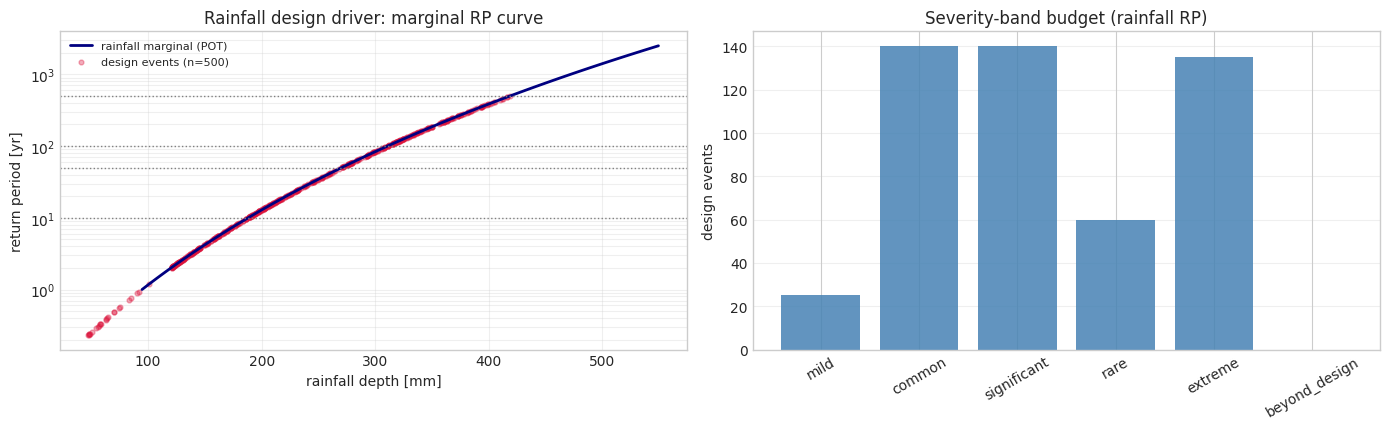

In [11]:
# rainfall marginal and selected event severity budget.
marg = inland_result.rainfall_marginal
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
rp_axis = np.logspace(0, np.log10(max(benchmark_return_periods) * 5), 120)
axes[0].plot([marg.magnitude(rp) for rp in rp_axis], rp_axis, "-", color="navy", lw=2, label="rainfall marginal (POT)")
axes[0].scatter(df_catalog["rainfall_mm"], df_catalog["sample_rp_years"], s=12, alpha=0.35, color="crimson", label=f"design events (n={len(df_catalog)})")
for rp in benchmark_return_periods:
    axes[0].axhline(rp, ls=":", color="0.5", lw=1)
axes[0].set_yscale("log")
axes[0].set_xlabel("rainfall depth [mm]")
axes[0].set_ylabel("return period [yr]")
axes[0].set_title("Rainfall design driver: marginal RP curve")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, which="both")

band_order = [b["severity_band"] for b in config["sampling"]["severity_bands"]]
counts = df_catalog["severity_band"].value_counts().reindex(band_order).fillna(0)
axes[1].bar(counts.index, counts.values, color="steelblue", alpha=0.85)
axes[1].set_title("Severity-band budget (rainfall RP)")
axes[1].set_ylabel("design events")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(True, alpha=0.3, axis="y")
fig.tight_layout()
plt.show()


### 3.2 Streamflow validation anchor (response target)

The reference-gage POT frequency curve the rainfall-driven, Wflow-generated discharge ensemble must reproduce after the single-K Same-Frequency Amplification. Shown so the response-based frequency target is explicit — it is not a design driver.

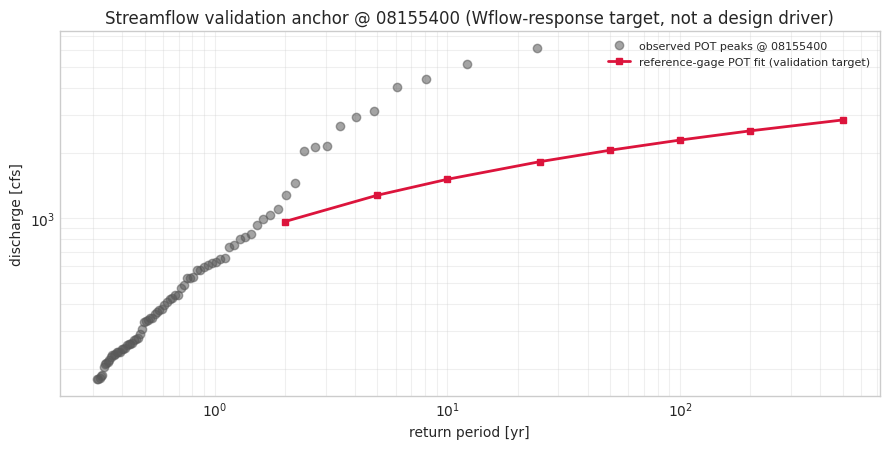

,streamflow_pot_cfs
2,965.0
5,1279.0
10,1516.0
25,1829.0
50,2067.0
100,2304.0
200,2541.0
500,2855.0


In [12]:
# streamflow response target for Wflow calibration/readiness.
ref_pot = inland_result.streamflow_reference_pot
fig, ax = plt.subplots(figsize=(9, 4.6))
obs = streamflow_pot_members.sort_values("peak_flow_cfs")
obs_rp = record_years / np.arange(len(obs), 0, -1)
ax.plot(obs_rp, obs["peak_flow_cfs"], "o", color="0.35", alpha=0.55, label=f"observed POT peaks @ {primary_reference_gage}")
if ref_pot is not None:
    ax.plot(ref_pot.index, ref_pot.values, "-s", color="crimson", lw=2, ms=4, label="reference-gage POT fit (validation target)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("return period [yr]")
ax.set_ylabel("discharge [cfs]")
ax.set_title(f"Streamflow validation anchor @ {primary_reference_gage} (Wflow-response target, not a design driver)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()
plt.show()

if ref_pot is not None:
    display(ref_pot.round(0).to_frame("streamflow_pot_cfs"))


### 3.3 Antecedent moisture conditioning

Antecedent soil-moisture state is the pre-storm wetness each design event carries into Wflow, sampled outside the copula. Seasonal coverage across the design set.

In [13]:
# antecedent soil-moisture coverage for design events.
amc_col = next((c for c in ["soil_moisture_member_id", "soil_moisture_member_time"] if c in df_catalog.columns), None)
if amc_col and df_catalog[amc_col].notna().any():
    fig, ax = plt.subplots(figsize=(9, 4))
    amc_months = pd.to_datetime(df_catalog.get("soil_moisture_member_time"), errors="coerce").dt.month.dropna()
    if not amc_months.empty:
        ax.hist(amc_months, bins=range(1, 14), color="seagreen", alpha=0.8, align="left", rwidth=0.85)
        ax.set_xlabel("antecedent state month")
        ax.set_ylabel("design events")
        ax.set_xticks(range(1, 13))
    ax.set_title("Antecedent moisture conditioning coverage (seasonal)")
    ax.grid(True, alpha=0.3, axis="y")
    fig.tight_layout()
    plt.show()
    display(pd.Series({
        "events_with_amc": int(df_catalog[amc_col].notna().sum()),
        "amc_coverage_fraction": round(float(df_catalog[amc_col].notna().mean()), 3),
    }, name="antecedent_moisture"))
else:
    print("No antecedent soil-moisture members attached (NWM soil_moisture.csv absent); AMC conditioning skipped.")


No antecedent soil-moisture members attached (NWM soil_moisture.csv absent); AMC conditioning skipped.


### 3.4 Design catalog summary

Severity coverage, return-period ranges, and rainfall depths across the rainfall-driven design catalog.

In [ ]:
# historical rainfall-driver distribution, then selected design-catalog coverage.
historical_rainfall_catalog = rainfall_members.copy()
historical_rainfall_catalog["rainfall_mm"] = pd.to_numeric(
    historical_rainfall_catalog[rainfall_value_column], errors="coerce"
)
historical_rainfall_catalog["sample_rp_years"] = inland_result.rainfall_marginal.return_period(
    historical_rainfall_catalog["rainfall_mm"].to_numpy(dtype=float)
)
historical_rainfall_catalog["severity_band"] = assign_severity_bands(
    historical_rainfall_catalog["sample_rp_years"], config["sampling"]["severity_bands"]
)
historical_rainfall_catalog["probability_weight"] = 1.0 / max(len(historical_rainfall_catalog), 1)

fig = P.plot_severity_bands(historical_rainfall_catalog.dropna(subset=["rainfall_mm", "sample_rp_years"]))
fig.suptitle("Historical rainfall-driver severity distribution", y=1.03)
P.plot_severity_bands(df_catalog);

summary = df_catalog.groupby("severity_band").agg(
    events=("event_id", "size"),
    rp_min=("sample_rp_years", "min"),
    rp_max=("sample_rp_years", "max"),
    rainfall_min_mm=("rainfall_mm", "min"),
    rainfall_max_mm=("rainfall_mm", "max"),
    prob_mass=("probability_weight", "sum"),
).reindex([b["severity_band"] for b in config["sampling"]["severity_bands"]]).dropna(how="all")
display(summary.round({"rp_min": 2, "rp_max": 2, "rainfall_min_mm": 1, "rainfall_max_mm": 1, "prob_mass": 4}))


## Stage 7 - Wflow readiness replay set

Severity-band coverage, benchmark return-period coverage, and row previews.

### 7.1 Selected Design Catalog Severity Ranges

These severity labels are keyed to pre-SFINCS AND return period from the fitted copula, not to flood-response AEP. The configured return-period ranges are shown first so the labels are concrete before plotting the design catalog.


In [ ]:
# severity-band ranges for selected design catalog.
severity_ranges = pd.DataFrame(config["sampling"]["severity_bands"])
severity_ranges["and_joint_return_period_range"] = severity_ranges.apply(
    lambda row: (
        f">= {row['rp_min_years']:g} yr" if pd.isna(row["rp_max_years"])
        else f"{row['rp_min_years']:g} to <{row['rp_max_years']:g} yr"
    ),
    axis=1,
)
severity_ranges["annual_chance_range"] = severity_ranges.apply(
    lambda row: (
        f"<= {100 / row['rp_min_years']:g}%" if pd.isna(row["rp_max_years"]) and row["rp_min_years"] > 0
        else (
            f"> {100 / row['rp_max_years']:g}% to <= {100 / row['rp_min_years']:g}%"
            if row["rp_min_years"] > 0 else f"> {100 / row['rp_max_years']:g}%"
        )
    ),
    axis=1,
)
display(severity_ranges[["severity_band", "and_joint_return_period_range", "annual_chance_range"]])


### 7.2 Resilience Stress/Training Coverage

The final resilience set is the configured 500-event band-stratified stress/training catalog. Keep the compact severity-band review and table preview; the candidate-pool budget plot is omitted because it repeats the selected-row allocation.


In [ ]:
# high-fidelity simulation budget coverage by severity.
stress_training_catalog = df_catalog.copy()
stress_summary = pd.Series({
    "stress_training_rows": len(stress_training_catalog),
    "sampling_scheme": stress_training_catalog["sampling_scheme"].iloc[0],
    "mild_rows": int((stress_training_catalog["severity_band"] == "mild").sum()),
    "mild_fraction": float((stress_training_catalog["severity_band"] == "mild").mean()),
    "probability_weight_sum": float(stress_training_catalog["probability_weight"].sum()),
    "benchmark_return_periods": benchmark_return_periods,
}, name="resilience_stress_training")
display(stress_summary)

stress_preview = stress_training_catalog.sort_values("sample_rp_years", ascending=False)
display(stress_preview[[
    "event_id", "sample_rp_years", "severity_band", "sampling_weight", "probability_weight",
    "rainfall_mm", "rainfall_member_id",
]].head(16).round({"sample_rp_years": 2, "sampling_weight": 3, "probability_weight": 8, "rainfall_mm": 1}))


## Stage 8 - Hand off to Wflow and SFINCS

Each design row is matched to the closest observed streamflow POT analog and closest rainfall member, then gets scale factors that downstream model builders can use to preserve observed temporal fields while scaling their magnitudes.


In [ ]:
# Wflow/SFINCS handoff artifacts from the selected inland catalog.
# Discharge is generated downstream by Wflow; member files are normalized location-relative.
stress_training_catalog = df_catalog.copy()
catalog_outputs = materialize_inland_catalog_outputs(
    runtime=runtime,
    event_catalog=df_catalog,
    stress_training_catalog=stress_training_catalog,
    selected_catalog_csv=output_catalog_csv,
    summary_fields={"validation_anchor_gage": primary_reference_gage},
)
df_catalog = catalog_outputs["event_catalog"]
stress_training_catalog = catalog_outputs["stress_training_catalog"]
scenario_catalog = catalog_outputs["scenario_catalog"]

P.plot_scaling(df_catalog, "rainfall");
display(catalog_outputs["preview"])
display(catalog_outputs["summary"])
